In [ ]:
import numpy as np                                                                                                                                 
import matplotlib.pyplot as plt                                                                                                                    
                                                                                                                                                    
# alpha grid, rozcięty w okolicy osobliwości alpha = 1                                                                                             
alpha_left  = np.linspace(0.001, 0.97, 300)                                                                                                        
alpha_right = np.linspace(1.03, 2.40, 300)                                                                                                         
snr_left  = -20 * np.log10(np.abs(1.0 - alpha_left))
snr_right = -20 * np.log10(np.abs(1.0 - alpha_right))                                                                                              

fig, ax = plt.subplots(figsize=(7, 4.2))                                                                                                           
ax.plot(alpha_left,  snr_left,  color='tab:blue', lw=2,
        label=r'$\mathrm{SNR}(\alpha s,\, s) = -20\log_{10}|1-\alpha|$')                                                                           
ax.plot(alpha_right, snr_right, color='tab:blue', lw=2)                                                                                            
                                                                                                                                                    
# pionowa asymptota                                                                                                                                
ax.axvline(1.0, color='gray', linestyle=':', linewidth=1, alpha=0.6)                                                                               
ax.text(1.03, 30, r'$\hat{s}=s\;\Rightarrow\;\mathrm{SNR}=+\infty$',
        fontsize=9, color='gray', va='top')                                                                                                        

# punkty z prozy: alpha=0,5 -> 6 dB; alpha=2 -> 0 dB                                                                                               
ax.scatter([0.5, 2.0], [6.02, 0.0], color='tab:red', zorder=5, s=40)
ax.annotate(r'$\alpha = 0{,}5 \;\to\; 6{,}0$ dB',                                                                                                  
            xy=(0.5, 6.02), xytext=(0.08, 13.5),
            fontsize=10, color='tab:red',                                                                                                          
            arrowprops=dict(arrowstyle='->', color='tab:red', lw=0.8))
ax.annotate(r'$\alpha = 2 \;\to\; 0$ dB',                                                                                                          
            xy=(2.0, 0.0), xytext=(1.55, -10),
            fontsize=10, color='tab:red',                                                                                                          
            arrowprops=dict(arrowstyle='->', color='tab:red', lw=0.8))
                                                                                                                                                
                                                                                                                                                    
ax.set_xlabel(r'współczynnik skalowania $\alpha$ (przy $\hat{s} = \alpha s$)')                                                                     
ax.set_ylabel('SDR [dB]')
ax.set_xlim(-0.05, 2.45)                                                                                                                           
ax.set_ylim(-15, 35)                                                                                                                               
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', frameon=True)                                                                                                         
plt.tight_layout()                                                                                                                                 

# odkomentuj żeby zapisać:                                                                                                                         
# plt.savefig('figures/02_01_snr_scale_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()   

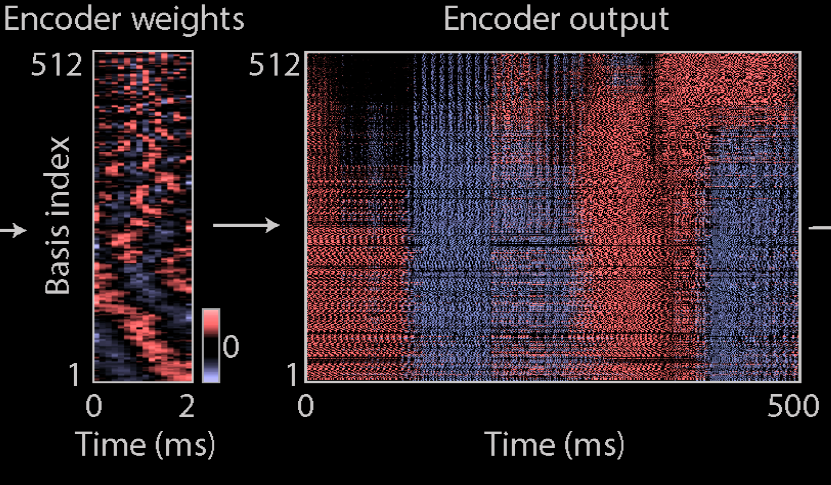

In [ ]:
import sys
from pathlib import Path

import numpy as np
import torch
import torchaudio
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec

REPO_ROOT = Path("/home/user/polsess_separation")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils import load_model_for_inference

AUDIO_PATH = Path("/home/user/datasets/PolSESS_C_new_64/PolSESS_C_new_64/train/clean/000mqbomjtudfgw5.wav")
CKPT_PATH = REPO_ROOT / "checkpoints/sepformer/SB/sepformer_SB_best-64k_baseline_posenc_v25/sepformer_SB_best.pt"

device = "cuda" if torch.cuda.is_available() else "cpu"

# --- 1. Load audio + spectrogram --------------------------------------------
waveform, sr = torchaudio.load(str(AUDIO_PATH))
waveform = waveform.mean(dim=0)  # mono
t_audio = np.arange(waveform.numel()) / sr
duration = waveform.numel() / sr

n_fft, hop = 512, 128
spec = torchaudio.transforms.Spectrogram(n_fft=n_fft, hop_length=hop, power=2.0)(waveform)
spec_db = 10.0 * torch.log10(spec.clamp(min=1e-10)).numpy()

# --- 2. SepFormer encoder ----------------------------------------------------
# Encoder weights = signed Conv1d kernel (red=+, blue=−, black=0).
# Encoder output = ReLU(Conv1d(x)) ≥ 0 — a single-speaker clip, so the right
# panel is just the magnitude of activation per filter over time on a
# sequential black→red colormap. The diverging red/blue scheme from the
# ConvTasNet paper's Fig. 2 right panel encodes speaker identity (M_i ⊙ enc),
# not value sign, and is not meaningful here since there's only one speaker.
model, _ = load_model_for_inference(str(CKPT_PATH), device=device)
model.eval()
m = model._orig_mod if hasattr(model, "_orig_mod") else model

W = m.encoder.conv1d.weight.detach().cpu().squeeze(1).numpy()  # [N, K] signed
N, K = W.shape
stride = m.encoder.conv1d.stride[0]

with torch.no_grad():
    enc = m.encoder(waveform.unsqueeze(0).to(device)).squeeze(0).cpu().numpy()  # [N, T], post-ReLU

# --- 3. Sort filters by FFT peak frequency + phase --------------------------
# Lexsort on (phase_at_peak, peak_bin) groups same-frequency filters together
# and orders them by phase within the group. `[::-1]` puts the highest-peak
# (high frequency) filter at row 0 of the sorted array, which combined with
# imshow's `extent=[..., N, 0]` places high freqs at the top of the panel and
# low freqs at the bottom — matching the paper.
F = np.fft.rfft(W, n=K, axis=1)
mag = np.abs(F)
peak = mag.argmax(axis=1)
phase = np.angle(F)[np.arange(N), peak]
order = np.lexsort((phase, peak))[::-1]

W_sorted = W[order]
enc_sorted = enc[order]

# --- 4. Per-row weight normalisation + colormaps ----------------------------
W_disp = W_sorted / (np.abs(W_sorted).max(axis=1, keepdims=True) + 1e-12)
enc_vmax = np.percentile(enc_sorted, 99.5)

blue_black_red = LinearSegmentedColormap.from_list(
    "blue_black_red",
    [(0.2, 0.4, 1.0), (0, 0, 0), (1.0, 0.2, 0.2)],
)
black_red = LinearSegmentedColormap.from_list(
    "black_red",
    [(0, 0, 0), (0.7, 0.0, 0.0), (1.0, 0.4, 0.4)],
)

t_enc = np.arange(enc_sorted.shape[1]) * stride / sr  # seconds, shared with waveform
t_weight_ms = 1000.0 * K / sr                          # kernel length in ms

# --- 5. Plot ----------------------------------------------------------------
# 12-column grid: main plots in cols 0-10, colorbar slot in col 11 (kept empty
# for the waveform so the three time-domain rows share an identical horizontal
# extent). White figure/axes background — black only enters through the two
# encoder colormaps (silence in the output panel, zero in the weights panel).
fig = plt.figure(figsize=(12, 13))
gs = GridSpec(4, 12, figure=fig, hspace=0.55, wspace=0.4,
              height_ratios=[1, 1.4, 1.4, 1.2])

ax_wave = fig.add_subplot(gs[0, 0:11])
ax_wave.plot(t_audio, waveform.numpy(), lw=0.5, color="tab:blue")
ax_wave.set_xlim(0, duration)
ax_wave.set_xlabel("Czas [s]")
ax_wave.set_ylabel("Amplituda")
ax_wave.set_title("1) Przebieg czasowy (waveform)")
ax_wave.grid(alpha=0.3)

ax_spec = fig.add_subplot(gs[1, 0:11], sharex=ax_wave)
cax_spec = fig.add_subplot(gs[1, 11])
freqs = np.linspace(0, sr / 2, spec_db.shape[0])
t_spec = np.arange(spec_db.shape[1]) * hop / sr
im_spec = ax_spec.imshow(
    spec_db, origin="lower", aspect="auto", cmap="magma",
    extent=[t_spec[0], t_spec[-1], freqs[0], freqs[-1]],
    vmin=spec_db.max() - 80, vmax=spec_db.max(),
)
ax_spec.set_xlim(0, duration)
ax_spec.set_xlabel("Czas [s]")
ax_spec.set_ylabel("Częstotliwość [Hz]")
ax_spec.set_title(f"2) Spektrogram (STFT, n_fft={n_fft}, hop={hop})")
fig.colorbar(im_spec, cax=cax_spec, label="[dB]")

ax_o = fig.add_subplot(gs[2, 0:11], sharex=ax_wave)
cax_o = fig.add_subplot(gs[2, 11])
im_o = ax_o.imshow(
    enc_sorted, aspect="auto", cmap=black_red,
    extent=[t_enc[0], t_enc[-1], N, 0],
    vmin=0, vmax=enc_vmax,
    interpolation="nearest",
)
ax_o.set_xlim(0, duration)
ax_o.set_xlabel("Czas [s]")
ax_o.set_ylabel("Indeks filtru (posort.)")
ax_o.set_title(f"3) Wyjście enkodera SepFormer — ReLU(Conv1d) (N={N}, K={K}, stride={stride})")
fig.colorbar(im_o, cax=cax_o, label="aktywacja")

ax_w = fig.add_subplot(gs[3, 0:4])
ax_w.imshow(
    W_disp, aspect="auto", cmap=blue_black_red,
    extent=[0, t_weight_ms, N, 0],
    vmin=-1, vmax=1,
    interpolation="nearest",
)
ax_w.set_xlabel("Czas [ms]")
ax_w.set_ylabel("Indeks filtru (posort.)")
ax_w.set_title("Wagi enkodera (jądro splotu, sort. wg częstotliwości szczytowej FFT)")

fig.suptitle(f"Trzy reprezentacje sygnału mowy — {AUDIO_PATH.name}", fontsize=13, y=0.995)
plt.show()

In [ ]:
# Tall side-by-side render of just the encoder weights + output, matching
# ConvTasNet Fig. 2. Reuses W_disp, enc_sorted, enc_vmax, t_weight_ms, t_enc,
# blue_black_red, black_red, N, K, stride from the cell above — re-run that
# cell first if the kernel was restarted.

fig = plt.figure(figsize=(14, 10))
gs = GridSpec(1, 14, figure=fig, wspace=0.08)

ax_w = fig.add_subplot(gs[0, 0:2])
ax_o = fig.add_subplot(gs[0, 2:13], sharey=ax_w)
cax = fig.add_subplot(gs[0, 13])

ax_w.imshow(
    W_disp, aspect="auto", cmap=blue_black_red,
    extent=[0, t_weight_ms, N, 0],
    vmin=-1, vmax=1,
    interpolation="nearest",
)
ax_w.set_xlabel("Czas [ms]")
ax_w.set_ylabel("Indeks filtru (sort. wg częstotliwości szczytowej FFT)")
ax_w.set_title("Wagi enkodera")

im_o = ax_o.imshow(
    enc_sorted, aspect="auto", cmap=black_red,
    extent=[t_enc[0], t_enc[-1], N, 0],
    vmin=0, vmax=enc_vmax,
    interpolation="nearest",
)
ax_o.set_xlabel("Czas [s]")
ax_o.tick_params(labelleft=False)
ax_o.set_title(f"Wyjście enkodera SepFormer — ReLU(Conv1d) (N={N}, K={K}, stride={stride})")

fig.colorbar(im_o, cax=cax, label="aktywacja")
# fig.suptitle("Filtry enkodera SepFormer i ich aktywacje w czasie",
#              fontsize=14, y=0.905)
plt.show()

In [ ]:
# 2-second variant of the waveform / spectrogram / encoder figure.
# Layout: waveform and spectrogram are offset right so their time axis lines
# up with the encoder output below; the encoder weights sit as a thin panel
# on the LEFT of the encoder output, sharing its filter-index axis.
# Reuses order, W_disp, blue_black_red, black_red, N, K, stride, t_weight_ms,
# n_fft, hop, sr, waveform, m, device from the cell above — re-run it first
# if the kernel was restarted.

CLIP_SECONDS = 2.0
clip_samples = int(CLIP_SECONDS * sr)

wave_clip = waveform[:clip_samples]
t_audio_clip = np.arange(wave_clip.numel()) / sr

spec_clip = torchaudio.transforms.Spectrogram(n_fft=n_fft, hop_length=hop, power=2.0)(wave_clip)
spec_clip_db = 10.0 * torch.log10(spec_clip.clamp(min=1e-10)).numpy()
t_spec_clip = np.arange(spec_clip_db.shape[1]) * hop / sr
freqs = np.linspace(0, sr / 2, spec_clip_db.shape[0])

with torch.no_grad():
    enc_clip = m.encoder(wave_clip.unsqueeze(0).to(device)).squeeze(0).cpu().numpy()
enc_clip_sorted = enc_clip[order]
t_enc_clip = np.arange(enc_clip_sorted.shape[1]) * stride / sr
enc_clip_vmax = np.percentile(enc_clip_sorted, 99.5)

# 14-col grid: weights in cols 0:2 (thin), main panels in cols 2:13, colorbar
# in col 13. Waveform/spectrogram start at col 2 so their x-axis matches the
# encoder output's x-axis exactly.
fig = plt.figure(figsize=(13, 11))
gs = GridSpec(3, 14, figure=fig, hspace=0.5, wspace=0.4,
              height_ratios=[1, 1.4, 1.7])

ax_wave = fig.add_subplot(gs[0, 2:13])
ax_wave.plot(t_audio_clip, wave_clip.numpy(), lw=0.6, color="tab:blue")
ax_wave.set_xlim(0, CLIP_SECONDS)
ax_wave.set_xlabel("Czas [s]")
ax_wave.set_ylabel("Amplituda")
ax_wave.set_title("1) Przebieg czasowy (pierwsze 2 s)")
ax_wave.grid(alpha=0.3)

ax_spec = fig.add_subplot(gs[1, 2:13], sharex=ax_wave)
cax_spec = fig.add_subplot(gs[1, 13])
im_spec = ax_spec.imshow(
    spec_clip_db, origin="lower", aspect="auto", cmap="magma",
    extent=[t_spec_clip[0], t_spec_clip[-1], freqs[0], freqs[-1]],
    vmin=spec_clip_db.max() - 80, vmax=spec_clip_db.max(),
)
ax_spec.set_xlim(0, CLIP_SECONDS)
ax_spec.set_xlabel("Czas [s]")
ax_spec.set_ylabel("Częstotliwość [Hz]")
ax_spec.set_title(f"2) Spektrogram (STFT, n_fft={n_fft}, hop={hop})")
fig.colorbar(im_spec, cax=cax_spec, label="[dB]")

ax_w = fig.add_subplot(gs[2, 0:2])
ax_w.imshow(
    W_disp, aspect="auto", cmap=blue_black_red,
    extent=[0, t_weight_ms, N, 0],
    vmin=-1, vmax=1,
    interpolation="nearest",
)
ax_w.set_xlabel("Czas [ms]")
ax_w.set_ylabel("Indeks filtru (posort.)")
ax_w.set_title("Wagi enkodera")

ax_o = fig.add_subplot(gs[2, 2:13], sharex=ax_wave, sharey=ax_w)
cax_o = fig.add_subplot(gs[2, 13])
im_o = ax_o.imshow(
    enc_clip_sorted, aspect="auto", cmap=black_red,
    extent=[t_enc_clip[0], t_enc_clip[-1], N, 0],
    vmin=0, vmax=enc_clip_vmax,
    interpolation="nearest",
)
ax_o.set_xlim(0, CLIP_SECONDS)
ax_o.set_xlabel("Czas [s]")
ax_o.tick_params(labelleft=False)
ax_o.set_title(f"3) Wyjście enkodera SepFormer — ReLU(Conv1d) (N={N}, K={K}, stride={stride})")
fig.colorbar(im_o, cax=cax_o, label="aktywacja")

fig.suptitle(f"Trzy reprezentacje sygnału mowy (pierwsze 2 s) — {AUDIO_PATH.name}",
             fontsize=13, y=0.995)
plt.show()


In [ ]:
# Same 2-second layout as above, but the encoder output panel shows the raw
# Conv1d response *before* ReLU — signed values, diverging colormap. Calls
# m.encoder.conv1d directly (needs an extra channel dim) to bypass the ReLU
# that m.encoder applies at the end.
# Reuses order, W_disp, blue_black_red, N, K, stride, t_weight_ms,
# n_fft, hop, sr, waveform, m, device from the cells above.

CLIP_SECONDS = 2.0
clip_samples = int(CLIP_SECONDS * sr)

wave_clip = waveform[:clip_samples]
t_audio_clip = np.arange(wave_clip.numel()) / sr

spec_clip = torchaudio.transforms.Spectrogram(n_fft=n_fft, hop_length=hop, power=2.0)(wave_clip)
spec_clip_db = 10.0 * torch.log10(spec_clip.clamp(min=1e-10)).numpy()
t_spec_clip = np.arange(spec_clip_db.shape[1]) * hop / sr
freqs = np.linspace(0, sr / 2, spec_clip_db.shape[0])

with torch.no_grad():
    # conv1d expects [B, 1, T]; output is [B, N, T_out].
    enc_clip_pre = m.encoder.conv1d(
        wave_clip.unsqueeze(0).unsqueeze(0).to(device)
    ).squeeze(0).cpu().numpy()
enc_clip_pre_sorted = enc_clip_pre[order]
t_enc_clip = np.arange(enc_clip_pre_sorted.shape[1]) * stride / sr
enc_pre_abs = np.percentile(np.abs(enc_clip_pre_sorted), 99.5)

# Signed power-law to compress dynamic range: sign(x) * (|x|/abs99)^gamma,
# clipped to [-1, 1]. gamma<1 boosts low-magnitude activations so the panel
# shows more colour without saturating the strong responses.
gamma = 0.5
enc_clip_pre_disp = (
    np.sign(enc_clip_pre_sorted)
    * np.clip(np.abs(enc_clip_pre_sorted) / enc_pre_abs, 0, 1) ** gamma
)

fig = plt.figure(figsize=(13, 11))
gs = GridSpec(3, 14, figure=fig, hspace=0.5, wspace=0.4,
              height_ratios=[1, 1.4, 1.7])

ax_wave = fig.add_subplot(gs[0, 2:13])
ax_wave.plot(t_audio_clip, wave_clip.numpy(), lw=0.6, color="tab:blue")
ax_wave.set_xlim(0, CLIP_SECONDS)
ax_wave.set_xlabel("Czas [s]")
ax_wave.set_ylabel("Amplituda")
ax_wave.set_title("1) Przebieg czasowy (pierwsze 2 s)")
ax_wave.grid(alpha=0.3)

ax_spec = fig.add_subplot(gs[1, 2:13], sharex=ax_wave)
cax_spec = fig.add_subplot(gs[1, 13])
im_spec = ax_spec.imshow(
    spec_clip_db, origin="lower", aspect="auto", cmap="magma",
    extent=[t_spec_clip[0], t_spec_clip[-1], freqs[0], freqs[-1]],
    vmin=spec_clip_db.max() - 80, vmax=spec_clip_db.max(),
)
ax_spec.set_xlim(0, CLIP_SECONDS)
ax_spec.set_xlabel("Czas [s]")
ax_spec.set_ylabel("Częstotliwość [Hz]")
ax_spec.set_title(f"2) Spektrogram (STFT, n_fft={n_fft}, hop={hop})")
fig.colorbar(im_spec, cax=cax_spec, label="[dB]")

ax_w = fig.add_subplot(gs[2, 0:2])
ax_w.imshow(
    W_disp, aspect="auto", cmap=blue_black_red,
    extent=[0, t_weight_ms, N, 0],
    vmin=-1, vmax=1,
    interpolation="nearest",
)
ax_w.set_xlabel("Czas [ms]", fontsize=10)
ax_w.set_ylabel("Indeks filtru")
ax_w.set_title("Wagi enkodera", fontsize=10)

ax_o = fig.add_subplot(gs[2, 2:13], sharex=ax_wave, sharey=ax_w)
cax_o = fig.add_subplot(gs[2, 13])
im_o = ax_o.imshow(
    enc_clip_pre_disp, aspect="auto", cmap=blue_black_red,
    extent=[t_enc_clip[0], t_enc_clip[-1], N, 0],
    vmin=-1, vmax=1,
    interpolation="nearest",
)
ax_o.set_xlim(0, CLIP_SECONDS)
ax_o.set_xlabel("Czas [s]")
ax_o.tick_params(labelleft=False)
ax_o.set_title(f"3) Wyjście enkodera SepFormer")

# Colorbar ticks expressed in original activation units so the gamma-warped
# scale stays interpretable. Tick positions are placed in display space
# (sign(x) * x**gamma), labels show the corresponding raw activation.
cbar_ticks_raw = np.array([-1.0, -0.5, -0.25, 0.0, 0.25, 0.5, 1.0])
cbar_ticks_disp = np.sign(cbar_ticks_raw) * np.abs(cbar_ticks_raw) ** gamma
cbar = fig.colorbar(im_o, cax=cax_o, label=f"aktywacja (gamma={gamma}, znorm. do p99,5)")
cbar.set_ticks(cbar_ticks_disp)
cbar.set_ticklabels([f"{v:+.2f}" if v else "0" for v in cbar_ticks_raw])

fig.suptitle(f"Trzy reprezentacje sygnału mowy (pierwsze 2 s, enkoder przed ReLU) — {AUDIO_PATH.name}",
             fontsize=13, y=0.995)
plt.show()


In [ ]:
# Same as the pre-ReLU + gamma cell above, but with the encoder weights panel
# dropped. All three rows (waveform, spectrogram, encoder output) span the
# full width and share the same time axis.
# Reuses order, blue_black_red, N, K, stride, n_fft, hop, sr, waveform, m,
# device from the cells above.

CLIP_SECONDS = 2.0
clip_samples = int(CLIP_SECONDS * sr)

wave_clip = waveform[:clip_samples]
t_audio_clip = np.arange(wave_clip.numel()) / sr

spec_clip = torchaudio.transforms.Spectrogram(n_fft=n_fft, hop_length=hop, power=2.0)(wave_clip)
spec_clip_db = 10.0 * torch.log10(spec_clip.clamp(min=1e-10)).numpy()
t_spec_clip = np.arange(spec_clip_db.shape[1]) * hop / sr
freqs = np.linspace(0, sr / 2, spec_clip_db.shape[0])

with torch.no_grad():
    enc_clip_pre = m.encoder.conv1d(
        wave_clip.unsqueeze(0).unsqueeze(0).to(device)
    ).squeeze(0).cpu().numpy()
enc_clip_pre_sorted = enc_clip_pre[order]
t_enc_clip = np.arange(enc_clip_pre_sorted.shape[1]) * stride / sr
enc_pre_abs = np.percentile(np.abs(enc_clip_pre_sorted), 99.5)

gamma = 0.5
enc_clip_pre_disp = (
    np.sign(enc_clip_pre_sorted)
    * np.clip(np.abs(enc_clip_pre_sorted) / enc_pre_abs, 0, 1) ** gamma
)

fig = plt.figure(figsize=(8, 10))
gs = GridSpec(3, 12, figure=fig, hspace=0.5, wspace=0.4,
              height_ratios=[1, 1.4, 1.7])

ax_wave = fig.add_subplot(gs[0, 0:11])
ax_wave.plot(t_audio_clip, wave_clip.numpy(), lw=0.6, color="tab:blue")
ax_wave.set_xlim(0, CLIP_SECONDS)
ax_wave.set_xlabel("Czas [s]")
ax_wave.set_ylabel("Amplituda")
ax_wave.set_title("1) Przebieg czasowy")
ax_wave.grid(alpha=0.3)

ax_spec = fig.add_subplot(gs[1, 0:11], sharex=ax_wave)
cax_spec = fig.add_subplot(gs[1, 11])
im_spec = ax_spec.imshow(
    spec_clip_db, origin="lower", aspect="auto", cmap="magma",
    extent=[t_spec_clip[0], t_spec_clip[-1], freqs[0], freqs[-1]],
    vmin=spec_clip_db.max() - 80, vmax=spec_clip_db.max(),
)
ax_spec.set_xlim(0, CLIP_SECONDS)
ax_spec.set_xlabel("Czas [s]")
ax_spec.set_ylabel("Częstotliwość [Hz]")
ax_spec.set_title(f"2) Spektrogram")
fig.colorbar(im_spec, cax=cax_spec, label="[dB]")

ax_o = fig.add_subplot(gs[2, 0:11], sharex=ax_wave)
cax_o = fig.add_subplot(gs[2, 11])
im_o = ax_o.imshow(
    enc_clip_pre_disp, aspect="auto", cmap=blue_black_red,
    extent=[t_enc_clip[0], t_enc_clip[-1], N, 0],
    vmin=-1, vmax=1,
    interpolation="nearest",
)
ax_o.set_xlim(0, CLIP_SECONDS)
ax_o.set_xlabel("Czas [s]")
ax_o.set_ylabel("Indeks filtru")
ax_o.set_title(f"3) Wyjście enkodera SepFormer")

cbar_ticks_raw = np.array([-1.0, -0.5, -0.25, 0.0, 0.25, 0.5, 1.0])
cbar_ticks_disp = np.sign(cbar_ticks_raw) * np.abs(cbar_ticks_raw) ** gamma
cbar = fig.colorbar(im_o, cax=cax_o, label=f"aktywacja")
cbar.set_ticks(cbar_ticks_disp)
cbar.set_ticklabels([f"{v:+.2f}" if v else "0" for v in cbar_ticks_raw])

fig.suptitle(f"Trzy reprezentacje sygnału mowy",
             fontsize=13, y=0.995)
plt.show()
